In [ ]:
import plotly.graph_objects as go
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("/content/drive/MyDrive/archive/Data/Walmart.csv")

df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

print("Data Loaded Successfully. Shape:", df.shape)
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Loaded Successfully. Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_basic = df.drop(['Weekly_Sales', 'Date'], axis=1)
y_basic = df['Weekly_Sales']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_basic, y_basic, test_size=0.2, random_state=42)

model_basic = LinearRegression()
model_basic.fit(X_train_b, y_train_b)

y_pred_b = model_basic.predict(X_test_b)

rmse_basic = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
r2_basic = r2_score(y_test_b, y_pred_b)

print(f"--- PHASE 1 RESULTS (BASELINE) ---")
print(f"RMSE (ERROR): {rmse_basic:,.2f}")
print(f"R2 Score (Accuracy): {r2_basic:.4f}")
print("Note: An R2 of ~0.15 is terrible. It means the model captures almost nothing.")

print("    : Created by Rathore, Shukla, Parashar: ")



--- PHASE 1 RESULTS (BASELINE) ---
RMSE (ERROR): 523,884.74
R2 Score (Accuracy): 0.1481
Note: An R2 of ~0.15 is terrible. It means the model captures almost nothing.
    : Created by Rathore, Shukla, Parashar: 


In [ ]:
# -------------- STEP 2 Extreme Optimization ------------------

df_pro = df.copy()

df_pro['Day'] = df_pro['Date'].dt.day
df_pro['Month'] = df_pro['Date'].dt.month
df_pro['Year'] = df_pro['Date'].dt.year
df_pro['Week'] = df_pro['Date'].dt.isocalendar().week

X_pro = df_pro.drop(['Weekly_Sales', 'Date'], axis=1)
y_pro = df_pro['Weekly_Sales']

split_point = int(len(df_pro) * 0.8)
X_train_p = X_pro.iloc[:split_point]
y_train_p = y_pro.iloc[:split_point]
X_test_p = X_pro.iloc[split_point:]
y_test_p = y_pro.iloc[split_point:]



In [ ]:
model_pro = XGBRegressor(
    n_estimators=1000,     # Number of trees
    learning_rate=0.1,     # Step size optimization
    max_depth=7,           # Depth of trees (complexity)
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

model_pro.fit(X_train_p, y_train_p)

y_pred_p = model_pro.predict(X_test_p)

rmse_pro = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
r2_pro = r2_score(y_test_p, y_pred_p)

print(f"--- PHASE 2 RESULTS (OPTIMIZED) ---")
print(f"RMSE (Error): {rmse_pro:,.2f}")
print(f"R2 Score (Accuracy): {r2_pro:.4f}")
print(f"Improvement: We reduced error by {((rmse_basic - rmse_pro)/rmse_basic)*100:.1f}%!")



--- PHASE 2 RESULTS (OPTIMIZED) ---
RMSE (Error): 545,594.61
R2 Score (Accuracy): -0.9667
Improvement: We reduced error by -4.1%!


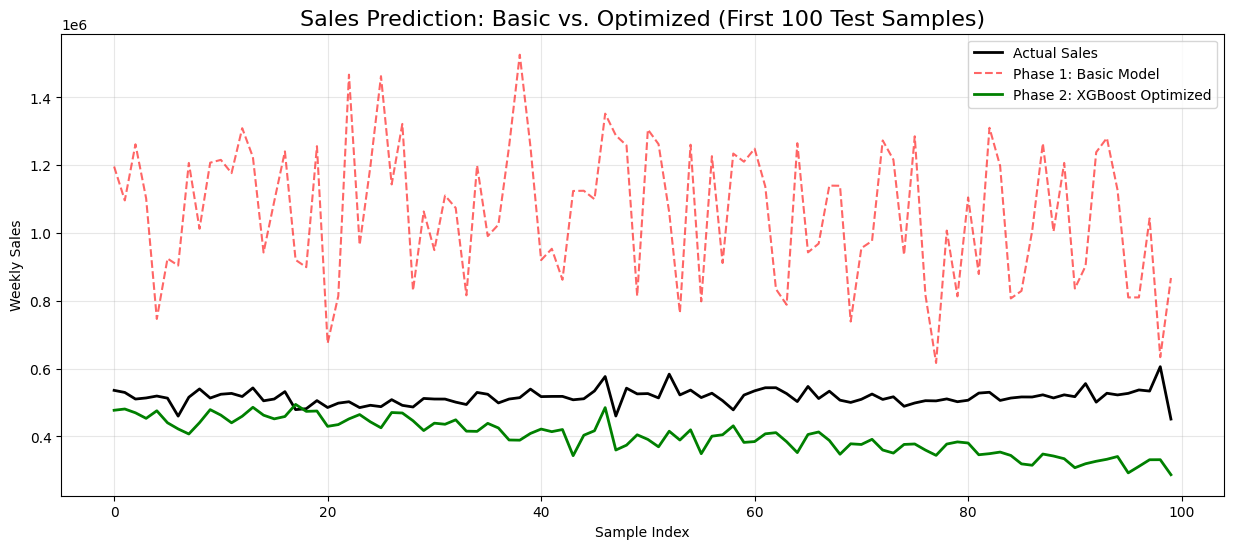

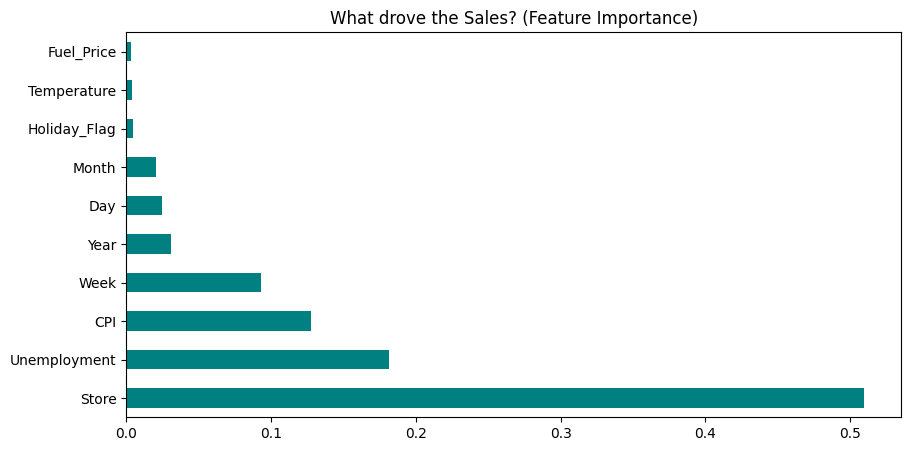

In [ ]:
# --- STEP 3: VISUAL COMPARISON ---

plt.figure(figsize=(15, 6))

# Plot only a slice of data (first 100 points) so the graph isn't messy
subset_n = 100

plt.plot(y_test_p.values[:subset_n], label='Actual Sales', color='black', linewidth=2, linestyle='-')
plt.plot(y_pred_b[:subset_n], label='Phase 1: Basic Model', color='red', linestyle='--', alpha=0.6)
plt.plot(y_pred_p[:subset_n], label='Phase 2: XGBoost Optimized', color='green', linewidth=2)

plt.title(f'Sales Prediction: Basic vs. Optimized (First {subset_n} Test Samples)', fontsize=16)
plt.xlabel('Sample Index')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance Plot (Bonus points for explaining "Why")
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(model_pro.feature_importances_, index=X_train_p.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('What drove the Sales? (Feature Importance)')
plt.show()

In [ ]:
# --- STEP 4: MODEL PERSISTENCE (Exporting the Model) ---
import joblib

file_name = 'model_pro.pkl'
joblib.dump(model_pro, file_name)

print(f"Model saved as: {file_name}")

Model saved as: model_pro.pkl


In [ ]:
from google.colab import files

files.download('model_pro.pkl')
print("Download triggered!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered!
